In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from study.d_01object_detect.bounding_box import *

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
from torchvision.io import read_image
from torchvision.transforms.functional import convert_image_dtype

from pathlib import Path

path = Path("study/d_01object_detect/catdog.jpg")
if not path.exists():
    path = Path("catdog.jpg")

img = read_image(path)                 # uint8 tensor: [C, H, W]
img = convert_image_dtype(img, float)  # float32, values in [0, 1]

c, h, w = img.shape

print(c,h,w)

X = torch.rand(size=(1,3,h,w))
Y = multibox_prior(X, sizes=[0.75, 0.5, 0.25], ratios=[1, 2, 0.5])

boxes_per_pixel = 5
boxes = Y[0].reshape(h, w, boxes_per_pixel, 4)

scale = torch.Tensor([w,h,w,h])
selected_boxes = boxes[250, 250]

3 561 728


In [3]:
boxes = Y.reshape(h,w,5,4)
boxes[250, 250,0, :]

tensor([0.0551, 0.0715, 0.6331, 0.8215])

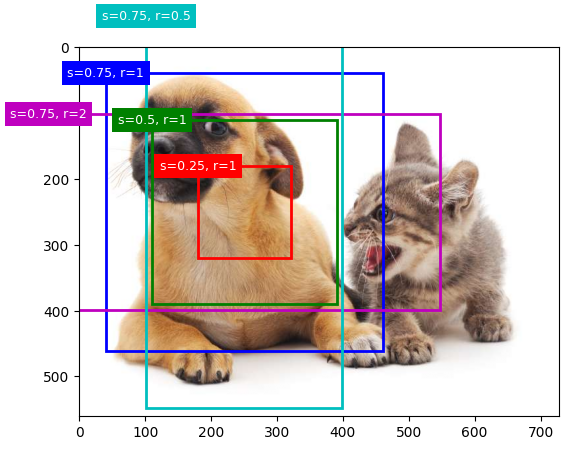

In [4]:
import matplotlib.patches as patches

scale = torch.tensor([w, h, w, h])

fig, ax = plt.subplots()
ax.imshow(img.permute(1, 2, 0))

show_bboxes(ax, boxes[250, 250, :, :] * scale,
            ['s=0.75, r=1', 's=0.5, r=1', 's=0.25, r=1', 's=0.75, r=2',
             's=0.75, r=0.5'])

plt.show()

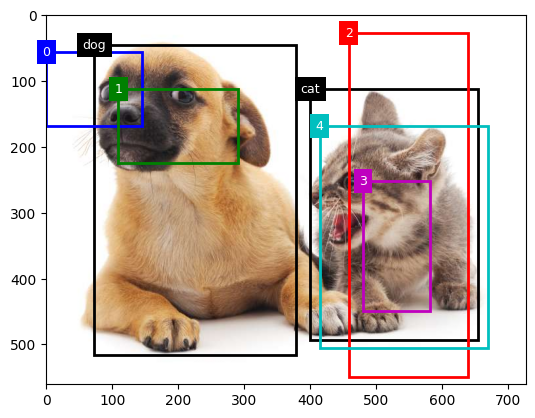

In [5]:
ground_truth = torch.tensor([[0, 0.1, 0.08, 0.52, 0.92],
                         [1, 0.55, 0.2, 0.9, 0.88]])
anchors = torch.tensor([[0, 0.1, 0.2, 0.3], [0.15, 0.2, 0.4, 0.4],
                    [0.63, 0.05, 0.88, 0.98], [0.66, 0.45, 0.8, 0.8],
                    [0.57, 0.3, 0.92, 0.9]])

fig, ax = plt.subplots()
ax.imshow(img.permute(1, 2, 0))

show_bboxes(ax, ground_truth[:, 1:] * scale, ['dog', 'cat'], colors=['k'])
show_bboxes(ax, anchors * scale, ['0', '1', '2', '3', '4'])

plt.show()